# Neural Networks: Backpropagation with Pure Python

This notebook shows how to:
- implement backpropagation in pure python

### Imports: only numpy and matplotlib

In [38]:


from numpy import array, zeros, exp, random, dot, shape, reshape, meshgrid, linspace, transpose

import matplotlib.pyplot as plt # for plotting
import matplotlib
matplotlib.rcParams['figure.dpi']=300 # highres display

# Backpropagation

We need backpropagation to **efficiently compute gradients** of the loss with respect to all weights in the network.

Without backpropagation, we'd have to compute each gradient separately by perturbing weights one at a time (finite differences), which is **exponentially slower** — O(n²) instead of O(n) operations.

Backpropagation uses the chain rule to reuse computations: the error at layer N automatically contains all the information needed to compute gradients for layer N-1, N-2, etc., in a single backward pass.

## Implement backpropagation for a general (fully connected) network

This defines the **sigmoid activation function** and its derivative:

- **`val = 1/(1+exp(-z))`** — The sigmoid function, squashing any real number into the range (0,1)

- **Returns both** `val` (the activation output) and `exp(-z)*val²` (the derivative)

The derivative formula simplifies to `f'(z) = f(z) * (1 - f(z))`, but here it's written in the mathematically equivalent form `exp(-z) * f(z)²`.

Returning both values together avoids recomputing the derivative during backpropagation.

In [14]:
def net_f_df(z): # calculate f(z) and f'(z)
    val=1/(1+exp(-z)) # sigmoid
    return(val,exp(-z)*(val**2)) # return both f and f'

This performs a **single forward pass through one layer**:

1. **`z = dot(y,w) + b`** — Computes weighted sum of inputs plus bias
2. **`net_f_df(z)`** — Applies sigmoid activation and returns both:
   - `f(z)` (output to pass to next layer)
   - `f'(z)` (stored for later backpropagation)

So it simultaneously computes the layer's output **and** saves the activation derivative needed when backpropagating through this layer.

In [15]:
def forward_step(y,w,b): # calculate values in next layer, from input y
    z=dot(y,w)+b # w=weights, b=bias vector for next layer
    return(net_f_df(z)) # apply nonlinearity and return result

This performs a **complete forward pass through the entire network**:

1. **Starts** with input `y_in` as the first layer's values
2. **Loops through every layer** — for each, calls `forward_step()` to compute outputs and activation derivatives
3. **Stores** all intermediate values (`y_layer` and `df_layer`) for later use during backpropagation
4. **Returns** the final network output

The stored values (`y_layer[j]` = neuron activations, `df_layer[j]` = activation derivatives) are essential because backpropagation needs them to compute gradients.

In [16]:
def apply_net(y_in): # one forward pass through the network
    global Weights, Biases, NumLayers
    global y_layer, df_layer # for storing y-values and df/dz values
    
    y=y_in # start with input values
    y_layer[0]=y
    for j in range(NumLayers): # loop through all layers
        # j=0 corresponds to the first layer above the input
        y,df=forward_step(y,Weights[j],Biases[j]) # one step
        df_layer[j]=df # store f'(z) [needed later in backprop]
        y_layer[j+1]=y # store f(z) [also needed in backprop]        
    return(y)

This is a **forward-only pass** that doesn't store intermediate values for backpropagation.

It's used for **inference/prediction** (testing) where you only need the output, not the gradients. It's the same calculation as `apply_net()` but without saving `df_layer` and `y_layer` since no backward pass will follow.

In [17]:
def apply_net_simple(y_in): # one forward pass through the network
    # no storage for backprop (this is used for simple tests)

    y=y_in # start with input values
    y_layer[0]=y
    for j in range(NumLayers): # loop through all layers
        # j=0 corresponds to the first layer above the input
        y,df=forward_step(y,Weights[j],Biases[j]) # one step
    return(y)

$$\delta^{(l-1)} = \left(\delta^{(l)} \cdot (W^{(l)})^T\right) \odot f'(z^{(l-1)})$$

**Explanation:** Multiply the error from the next layer ($\delta^{(l)}$) by the transposed weights to propagate it backward, then scale by the activation derivative ($f'$) to account for how sensitive the current layer's output was to its input.

The chain rule states: if $L$ depends on $z^{(l)}$, and $z^{(l)}$ depends on $z^{(l-1)}$, then:

$$\frac{\partial L}{\partial z^{(l-1)}} = \frac{\partial L}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial z^{(l-1)}}$$

Here:
- $\frac{\partial L}{\partial z^{(l)}} = \delta^{(l)}$ (incoming error)
- $\frac{\partial z^{(l)}}{\partial z^{(l-1)}} = (W^{(l)})^T \odot f'(z^{(l-1)})$ (since $z^{(l)} = W^{(l)} f(z^{(l-1)}) + b$)

Multiply them: $\delta^{(l-1)} = \delta^{(l)} \cdot (W^{(l)})^T \odot f'(z^{(l-1)})$

In [18]:
def backward_step(delta,w,df): 
    # delta at layer N, of batchsize x layersize(N))
    # w between N-1 and N [layersize(N-1) x layersize(N) matrix]
    # df = df/dz at layer N-1, of batchsize x layersize(N-1)
    return( dot(delta,transpose(w))*df )

This function performs **one full backward pass** through a neural network to compute gradients of the loss with respect to all weights and biases.

## What it does:

1. **Output layer**: Computes error `delta = (prediction - target) * derivative` (for cross-entropy or MSE loss)

2. **Backpropagates** from last layer to first: For each layer, calls `backward_step()` to compute the previous layer's delta using the chain rule

3. **Stores gradients**:
   - `dw_layer[j]` = gradient of loss w.r.t. weights in layer j
   - `db_layer[j]` = gradient of loss w.r.t. biases in layer j
   - Divides by `batchsize` to get average gradient over the batch

These gradients are later used to update weights via gradient descent: `weight = weight - learning_rate * dw`

In [19]:
def backprop(y_target): # one backward pass through the network
    # the result will be the 'dw_layer' matrices that contain
    # the derivatives of the cost function with respect to
    # the corresponding weight
    global y_layer, df_layer, Weights, Biases, NumLayers
    global dw_layer, db_layer # dCost/dw and dCost/db (w,b=weights,biases)
    global batchsize
    
    delta=(y_layer[-1]-y_target)*df_layer[-1] # cost function
    dw_layer[-1]=dot(transpose(y_layer[-2]),delta)/batchsize # grad wrt weights
    db_layer[-1]=delta.sum(0)/batchsize
    for j in range(NumLayers-1):
        delta=backward_step(delta,Weights[-1-j],df_layer[-2-j])
        dw_layer[-2-j]=dot(transpose(y_layer[-3-j]),delta)
        db_layer[-2-j]=delta.sum(0)/batchsize

## **gradient descent** 

This performs **gradient descent** — updating the network's weights and biases to reduce the loss.

For each layer, it subtracts a small fraction (`eta`, the learning rate) of the computed gradient (`dw`, `db`) from the current parameters. Moving opposite to the gradient direction lowers the loss function.

In [20]:
def gradient_step(eta): # update weights & biases (after backprop!)
    global dw_layer, db_layer, Weights, Biases
    
    for j in range(NumLayers):
        Weights[j]-=eta*dw_layer[j]
        Biases[j]-=eta*db_layer[j]

This function performs **one complete training step** on a batch of data:

1. **Forward pass** (`apply_net`): Computes network outputs for the given inputs
2. **Backward pass** (`backprop`): Computes gradients of the loss
3. **Gradient update** (`gradient_step`): Adjusts weights and biases using the gradients
4. **Return**: The average squared error (MSE) cost for monitoring progress

So it's the standard **forward → backward → update** loop for one batch.

In [21]:
def train_net(y_in,y_target,eta): # one full training batch
    # y_in is an array of size batchsize x (input-layer-size)
    # y_target is an array of size batchsize x (output-layer-size)
    # eta is the stepsize for the gradient descent
    global y_out_result
    
    y_out_result=apply_net(y_in)
    backprop(y_target)
    gradient_step(eta)
    cost=((y_target-y_out_result)**2).sum()/batchsize
    return(cost)

## Setup for a particular set of layer sizes

In [22]:
# set up all the weights and biases

NumLayers=3 # does not count input-layer (but does count output)
LayerSizes=[2,20,30,1] # input-layer,hidden-1,hidden-2,...,output-layer

# initialize random weights and biases for all layers (except input of course)
Weights=[random.uniform(low=-1,high=+1,size=[ LayerSizes[j],LayerSizes[j+1] ]) for j in range(NumLayers)]
Biases=[random.uniform(low=-1,high=+1,size=LayerSizes[j+1]) for j in range(NumLayers)]

# define the batchsize
batchsize=100

In [23]:
# set up all the helper variables

y_layer=[zeros([batchsize,LayerSizes[j]]) for j in range(NumLayers+1)]
df_layer=[zeros([batchsize,LayerSizes[j+1]]) for j in range(NumLayers)]
dw_layer=[zeros([LayerSizes[j],LayerSizes[j+1]]) for j in range(NumLayers)]
db_layer=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]

## Train the net on one single batch repeatedly (not so good)

In [24]:
y_in=random.uniform(low=-1,high=+1,size=[batchsize,LayerSizes[0]])
y_target=random.uniform(low=-1,high=+1,size=[batchsize,LayerSizes[-1]])

In [39]:
# one training step:
train_net(y_in,y_target,.0001) # returns cost function value

0.005440306936524819

In [26]:
eta=0.001
batches=200

costs=zeros(batches) # array to store the costs

for k in range(batches):
    costs[k]=train_net(y_in,y_target,eta)

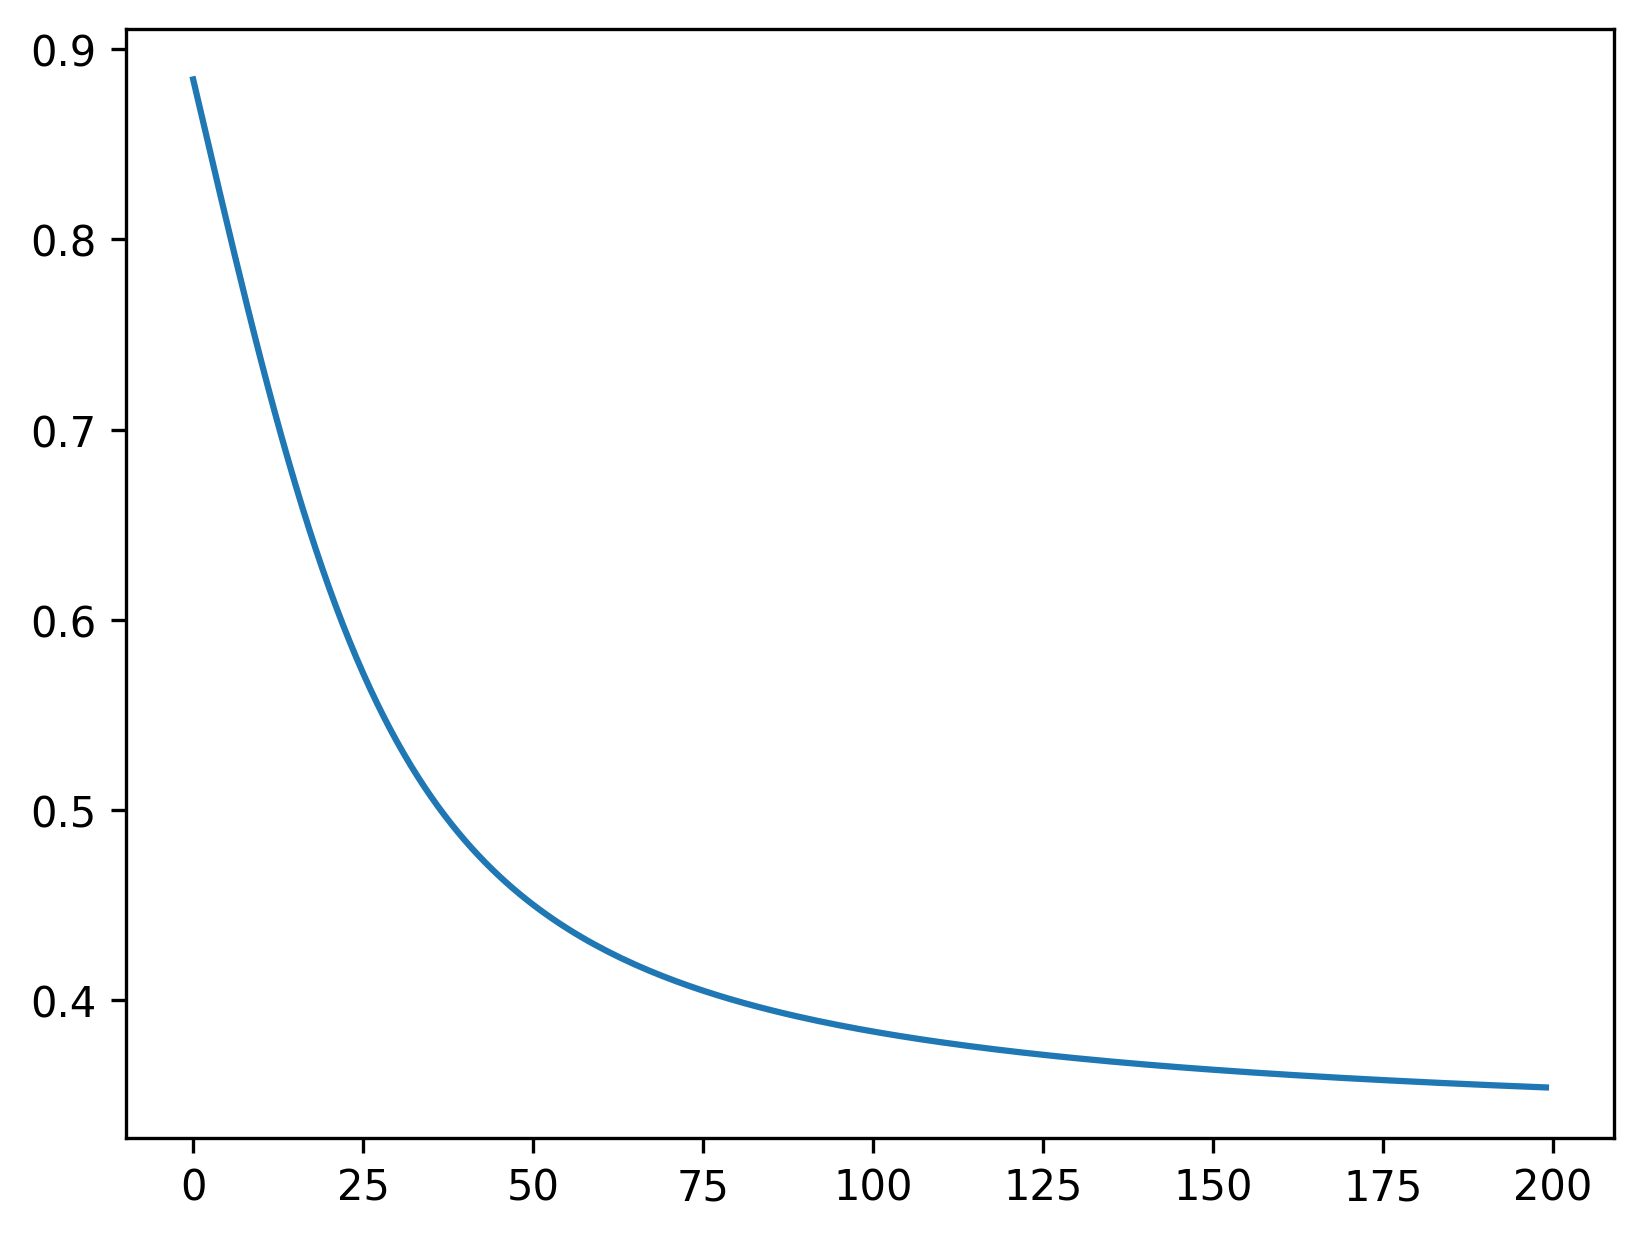

In [27]:
# this will show a very simple decrease, because
# we are not yet stochastically sampling inputs
# (it is always the SAME input! so the network
# only becomes good for that input)
plt.plot(costs)
plt.show()

### Produce random batches: randomly sample a function defined on a 2D square

In [28]:
# For a change: Set up rectified linear units (relu) 
# instead of sigmoid
def net_f_df(z): # calculate f(z) and f'(z)
    val=z*(z>0)
    return(val,z>0) # return both f and f'

In [29]:
# set up all the weights and biases

NumLayers=2 # does not count input-layer (but does count output)
LayerSizes=[2,100,1] # input-layer,hidden-1,hidden-2,...,output-layer

Weights=[random.uniform(low=-0.1,high=+0.1,size=[ LayerSizes[j],LayerSizes[j+1] ]) for j in range(NumLayers)]
Biases=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]

# set up all the helper variables

y_layer=[zeros(LayerSizes[j]) for j in range(NumLayers+1)]
df_layer=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]
dw_layer=[zeros([LayerSizes[j],LayerSizes[j+1]]) for j in range(NumLayers)]
db_layer=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]

In [30]:
# define the batchsize
batchsize=100

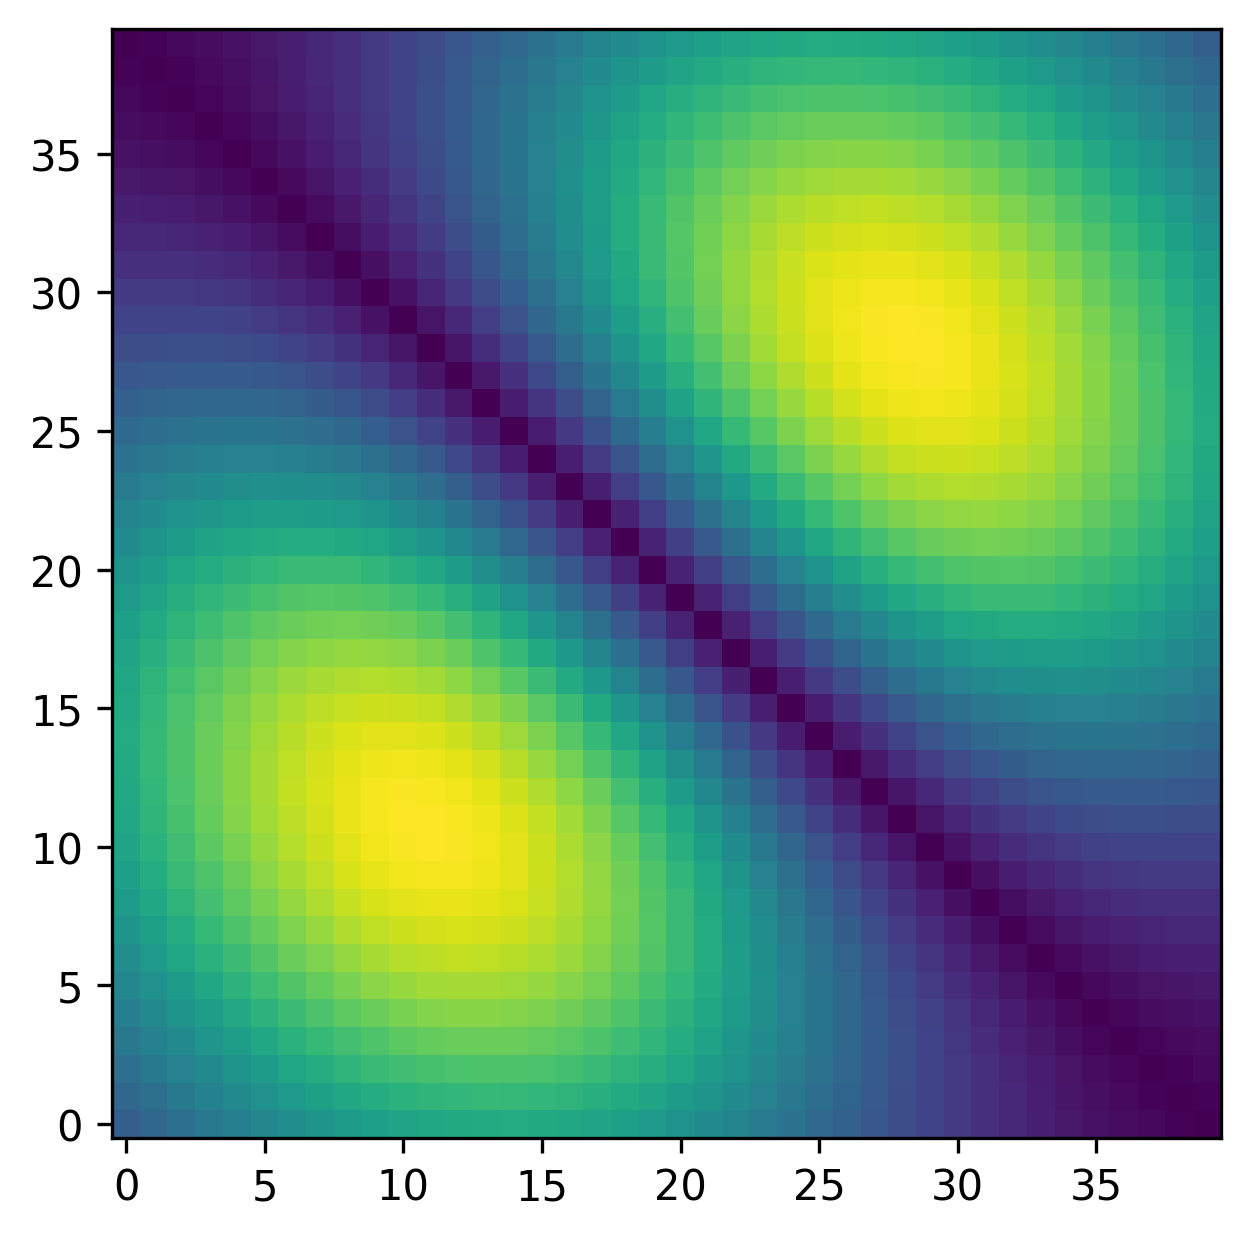

In [31]:
def myFunc(x0,x1):
    r2=x0**2+x1**2
    return(exp(-5*r2)*abs(x1+x0))

xrange=linspace(-0.5,0.5,40)
X0,X1=meshgrid(xrange,xrange)
plt.imshow(myFunc(X0,X1),interpolation='nearest',origin='lower')
plt.show()

In [32]:
def make_batch():
    global batchsize

    inputs=random.uniform(low=-0.5,high=+0.5,size=[batchsize,2])
    targets=zeros([batchsize,1]) # must have right dimensions
    targets[:,0]=myFunc(inputs[:,0],inputs[:,1])
    return(inputs,targets)

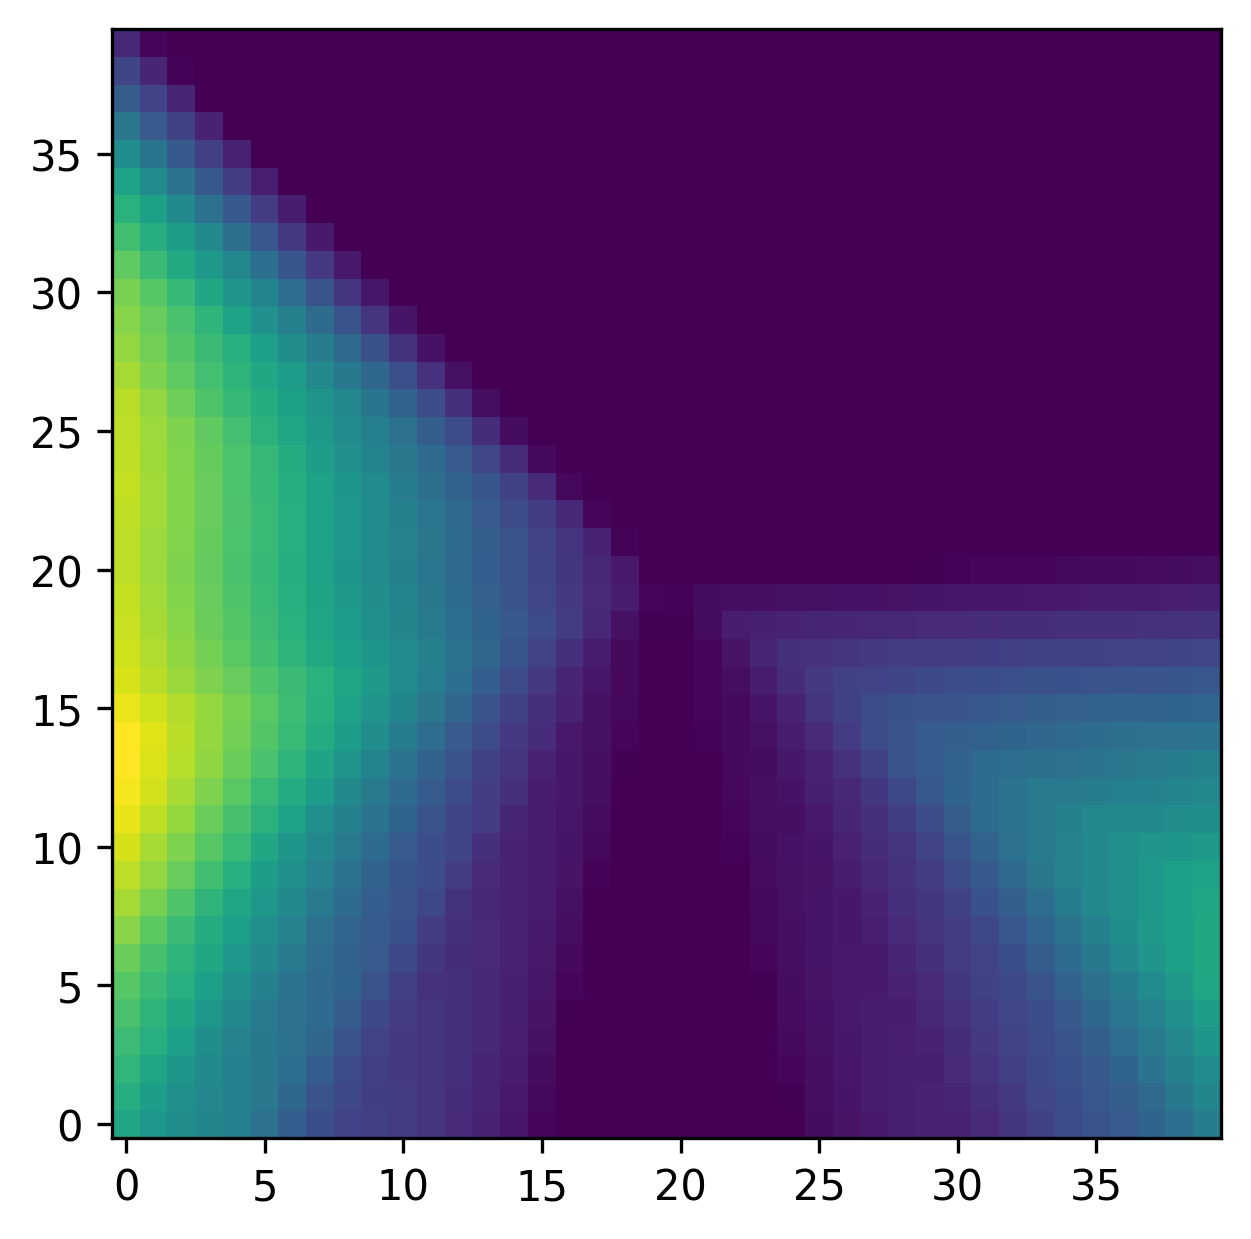

In [33]:
# try to evaluate the (randomly initialized) network
# on some area in the 2D plane
test_batchsize=shape(X0)[0]*shape(X0)[1]
testsample=zeros([test_batchsize,2])
testsample[:,0]=X0.flatten()
testsample[:,1]=X1.flatten()

testoutput=apply_net_simple(testsample)
myim=plt.imshow(reshape(testoutput,shape(X0)),origin='lower',interpolation='none')
plt.show()

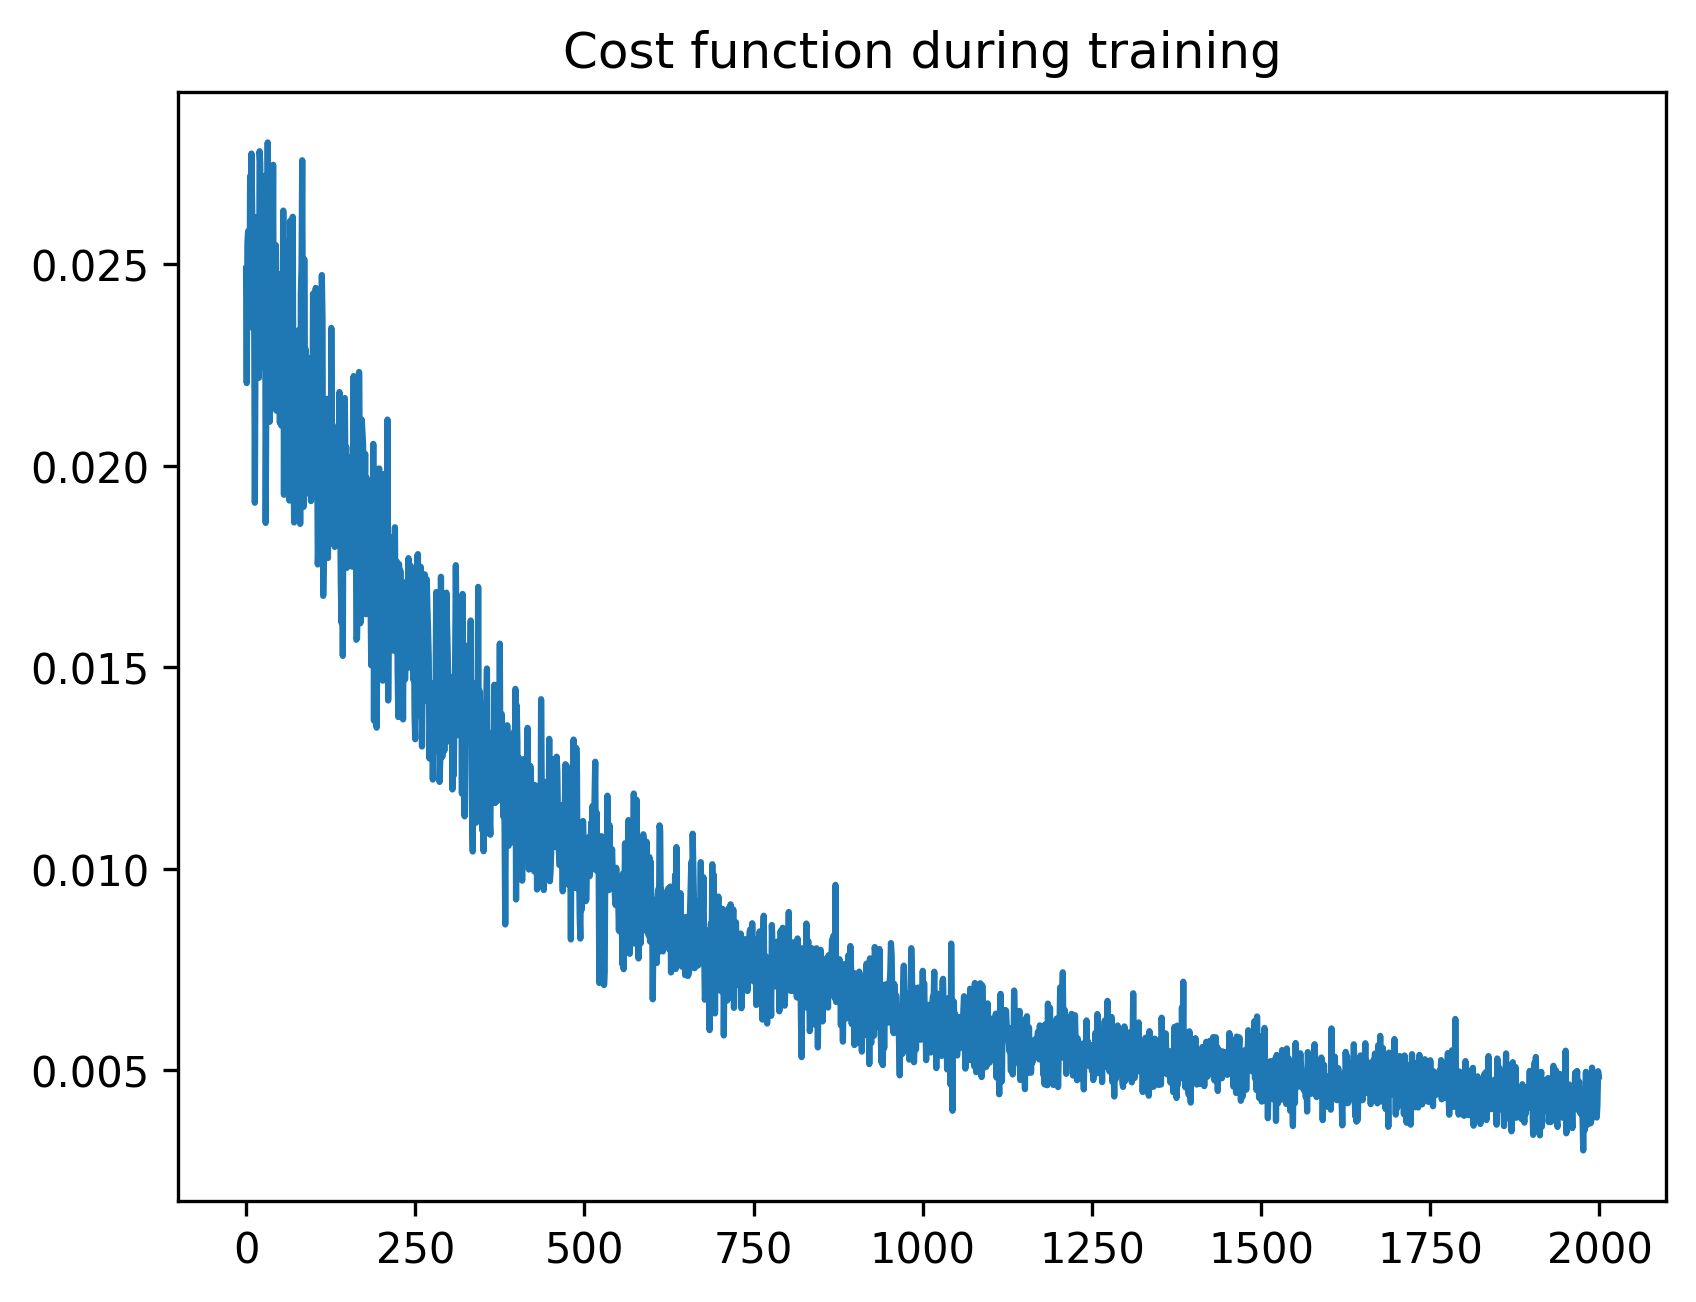

In [34]:
# now train on randomly sampled points
# to make the network reproduce better and
# better this 2D function!
eta=.001
batches=2000
costs=zeros(batches)

for k in range(batches):
    y_in,y_target=make_batch()
    costs[k]=train_net(y_in,y_target,eta)

plt.plot(costs)
plt.title("Cost function during training")
plt.show()


# Animate the network results during training

In [35]:
# start fresh:

# set up all the weights and biases

NumLayers=2 # does not count input-layer (but does count output)
LayerSizes=[2,100,1] # input-layer,hidden-1,hidden-2,...,output-layer

Weights=[random.uniform(low=-0.1,high=+0.1,size=[ LayerSizes[j],LayerSizes[j+1] ]) for j in range(NumLayers)]
Biases=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]

# set up all the helper variables

y_layer=[zeros(LayerSizes[j]) for j in range(NumLayers+1)]
df_layer=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]
dw_layer=[zeros([LayerSizes[j],LayerSizes[j+1]]) for j in range(NumLayers)]
db_layer=[zeros(LayerSizes[j+1]) for j in range(NumLayers)]

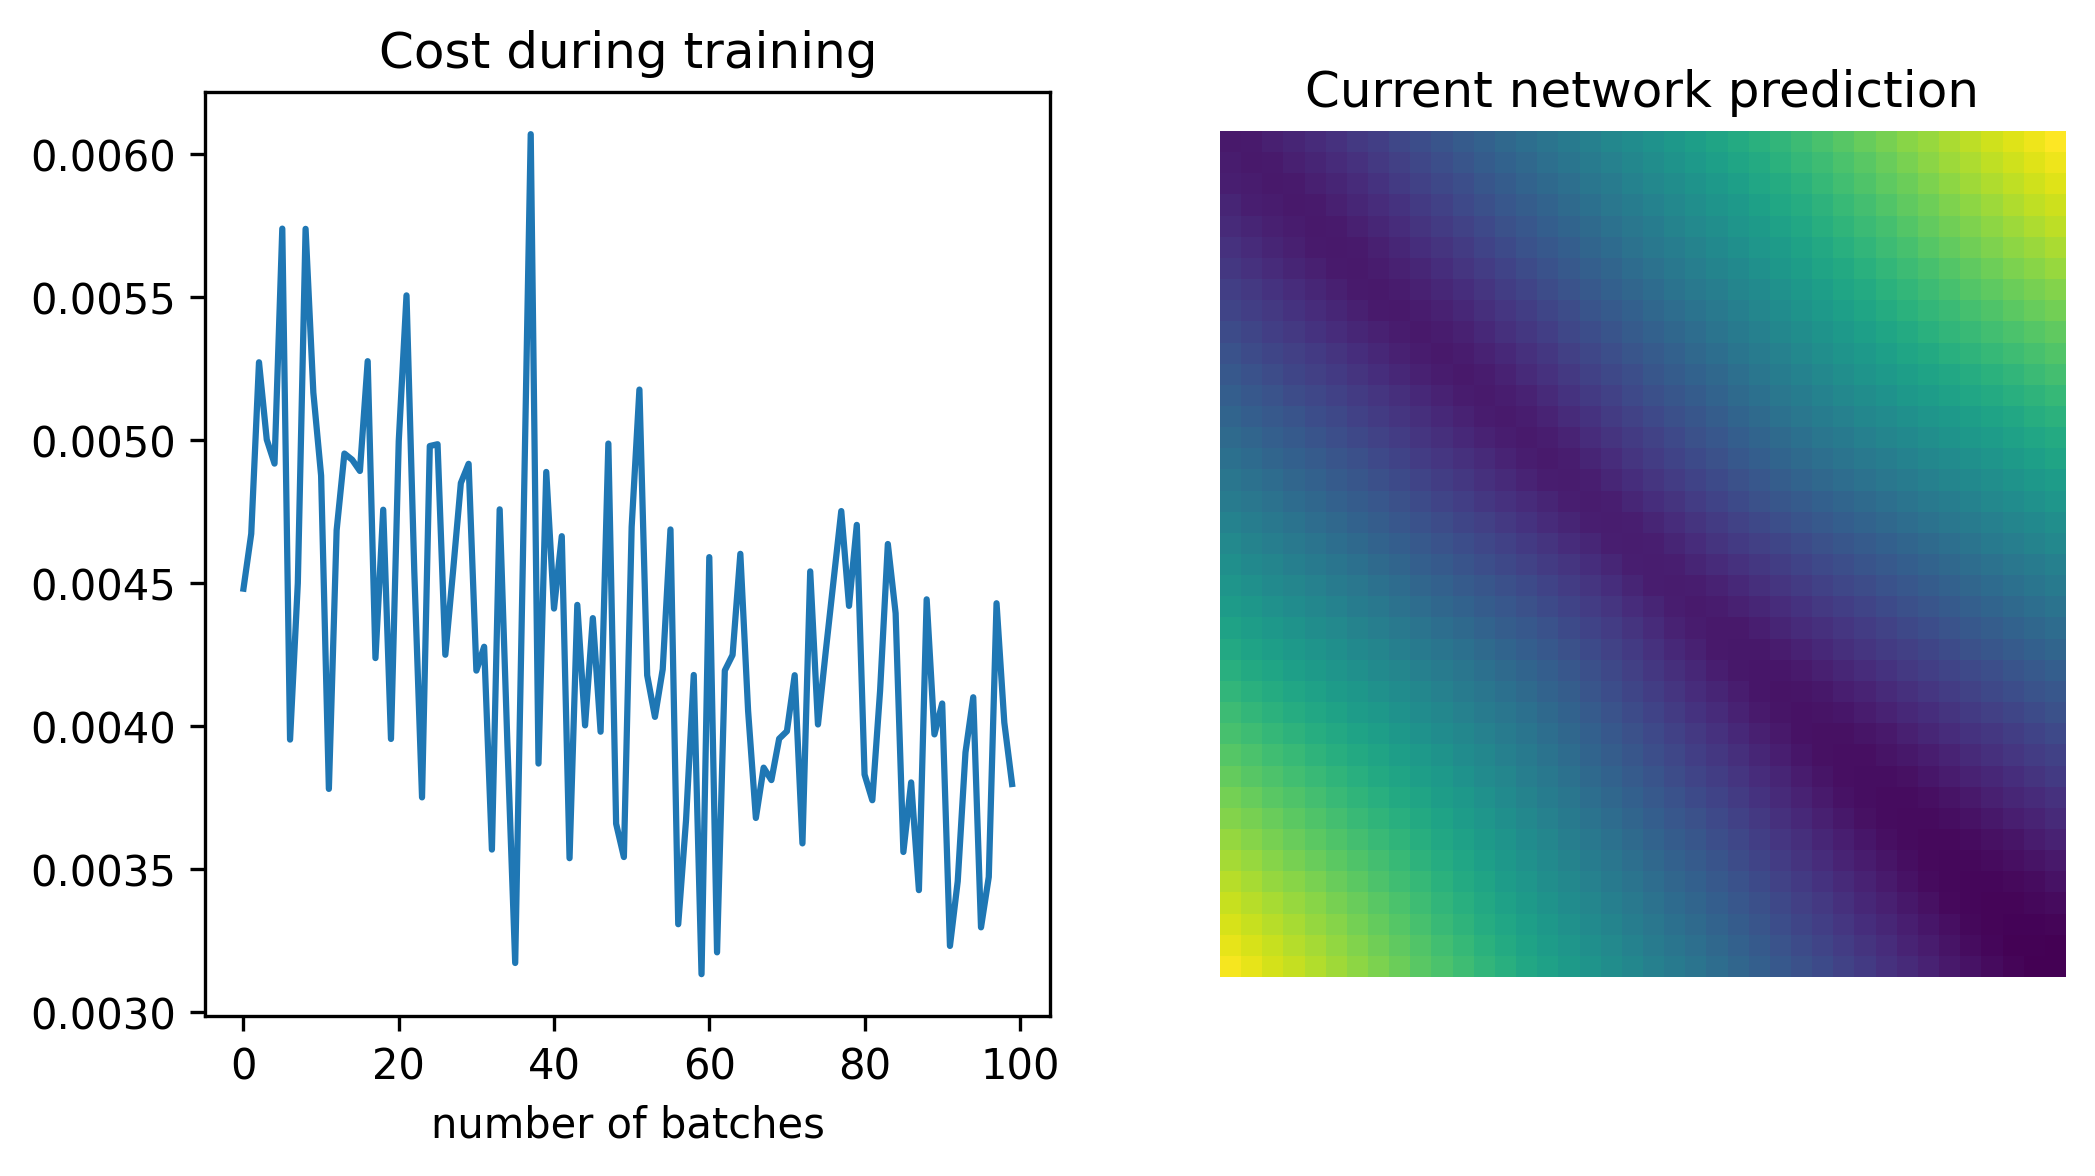

In [40]:
# import functions for updating display 
# (simple animation)
from IPython.display import clear_output
from time import sleep

eta=0.01 # learning rate
nsteps=100

costs=zeros(nsteps)
for j in range(nsteps):
    clear_output(wait=True)
    fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(8,4)) # prepare figure
    ax[1].axis('off') # no axes
    
    # the crucial lines:
    y_in,y_target=make_batch() # random samples (points in 2D)
    costs[j]=train_net(y_in,y_target,eta) # train network (one step, on this batch)
    testoutput=apply_net_simple(testsample) # check the new network output in the plane
    
    img=ax[1].imshow(reshape(testoutput,shape(X0)),interpolation='nearest',origin='lower') # plot image
    ax[0].plot(costs)
    
    ax[0].set_title("Cost during training")
    ax[0].set_xlabel("number of batches")
    ax[1].set_title("Current network prediction")
    plt.show()
    sleep(0.1)